# Exploración de datos — BrokerHub

Notebook para probar y visualizar los datos que trae `cliente_finnhub.py` antes de insertarlos en MySQL:
- Perfil de empresa (Finnhub)
- Precio actual (Finnhub)
- Clasificación por capitalización
- Histórico diario (yfinance)

In [1]:
import pandas as pd
from cliente_finnhub import (
    obtener_perfil_empresa,
    obtener_precio_actual,
    obtener_historico,
    clasificar_por_capitalizacion,
)

pd.set_option("display.max_columns", None)

## 1. Define la lista de tickers a probar

In [2]:
tickers = ["AAPL", "MSFT", "NVDA", "XOM", "JPM"]

## 2. Perfil de empresa + clasificación por capitalización
Trae el perfil de cada ticker y arma una tabla resumen (esto alimenta `Emisor`, `Instrumento_Financiero` y `Categoria_Instrumento`).

In [3]:
filas_perfil = []

for ticker in tickers:
    perfil = obtener_perfil_empresa(ticker)
    categoria = clasificar_por_capitalizacion(perfil.get("marketCapitalization"))
    filas_perfil.append({
        "ticker": ticker,
        "razon_social": perfil.get("name"),
        "sector": perfil.get("finnhubIndustry"),
        "pais": perfil.get("country"),
        "market_cap_millones": perfil.get("marketCapitalization"),
        "categoria_nivel3": categoria,
        "fecha_ipo": perfil.get("ipo"),
    })

df_perfiles = pd.DataFrame(filas_perfil)
df_perfiles

,ticker,razon_social,sector,pais,market_cap_millones,categoria_nivel3,fecha_ipo
0,AAPL,Apple Inc,Technology,US,4.901758e+06,Blue Chip,1980-12-12
1,MSFT,Microsoft Corp,Technology,US,2.925466e+06,Blue Chip,1986-03-13
2,NVDA,NVIDIA Corp,Semiconductors,US,4.908002e+06,Blue Chip,1999-01-22
3,XOM,Exxon Mobil Corp,Energy,US,5.880022e+05,Blue Chip,1980-03-17
4,JPM,JPMorgan Chase & Co,Banking,US,9.139813e+05,Blue Chip,1969-03-05


## 3. Precio actual de cada ticker
Esto es una "foto" del momento — no se guarda tal cual en ninguna tabla histórica, pero sirve para validar que los datos tengan sentido.

In [4]:
filas_precio = []

for ticker in tickers:
    precio = obtener_precio_actual(ticker)
    filas_precio.append({
        "ticker": ticker,
        "precio_actual": precio.get("c"),
        "apertura": precio.get("o"),
        "maximo": precio.get("h"),
        "minimo": precio.get("l"),
        "cierre_anterior": precio.get("pc"),
    })

df_precios = pd.DataFrame(filas_precio)
df_precios

,ticker,precio_actual,apertura,maximo,minimo,cierre_anterior
0,AAPL,333.74,331.980,334.990,329.0006,333.26
1,MSFT,393.82,394.855,398.390,389.3900,401.10
2,NVDA,202.81,202.640,206.645,197.9700,207.40
3,XOM,147.36,149.030,150.000,147.1700,145.95
4,JPM,341.10,339.030,346.125,335.0500,343.15


## 4. Histórico diario (yfinance)
Se trae por separado para cada ticker (esto llena `Cotizacion_Historica`). Aquí mostramos solo AAPL como ejemplo.

In [5]:
historico_aapl = obtener_historico("AAPL", periodo="3mo")
df_historico = pd.DataFrame(historico_aapl)
df_historico.tail(10)

,fecha,precio_apertura,precio_cierre,precio_maximo,precio_minimo,volumen
52,2026-07-06,307.36,312.66,314.20,307.00,53590000
53,2026-07-07,315.29,310.66,315.48,310.15,42490000
54,2026-07-08,311.91,313.39,314.82,307.05,41323500
55,2026-07-09,310.51,316.22,316.53,308.16,48124500
56,2026-07-10,314.72,315.32,316.91,312.17,34132300
57,2026-07-13,317.02,317.31,323.45,315.78,43257800
58,2026-07-14,313.76,314.86,316.19,311.91,36336800
59,2026-07-15,317.62,327.50,328.73,317.32,60957600
60,2026-07-16,328.01,333.26,334.68,326.79,62970600
61,2026-07-17,331.98,333.74,334.99,329.00,63365300


## 5. (Opcional) Graficar el precio de cierre para revisar visualmente

<Axes: title={'center': 'AAPL - Precio de cierre'}, xlabel='fecha'>

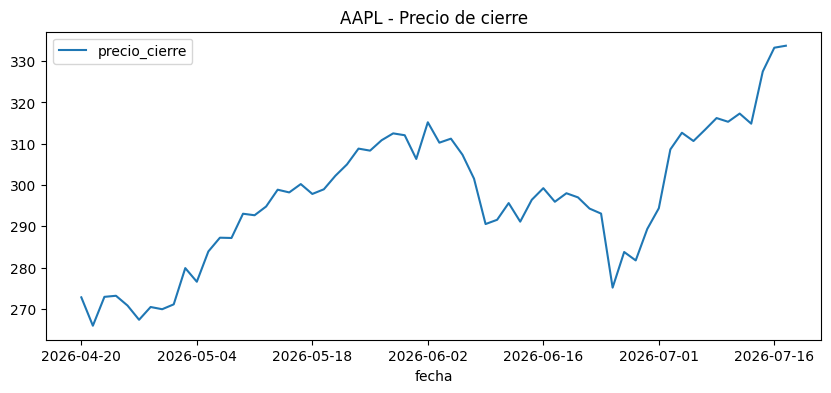

In [6]:
df_historico.plot(x="fecha", y="precio_cierre", figsize=(10, 4), title="AAPL - Precio de cierre")

## 6. Traer histórico para TODOS los tickers a la vez
Junta todo en un solo DataFrame, listo para revisar antes de insertarlo en `Cotizacion_Historica`.

In [7]:
todos_historicos = []

for ticker in tickers:
    filas = obtener_historico(ticker, periodo="3mo")
    for fila in filas:
        fila["ticker"] = ticker
        todos_historicos.append(fila)

df_todos = pd.DataFrame(todos_historicos)
print(f"Total de filas: {len(df_todos)}")
df_todos.head(10)

Total de filas: 310


,fecha,precio_apertura,precio_cierre,precio_maximo,precio_minimo,volumen,ticker
0,2026-04-20,270.0811,272.7986,274.0275,270.0412,36590200,AAPL
1,2026-04-21,271.2501,265.9250,272.5489,265.1557,50209800,AAPL
2,2026-04-22,267.5735,272.9186,273.4880,266.6244,43249200,AAPL
3,2026-04-23,274.7968,273.1783,275.5162,271.4000,33399600,AAPL
4,2026-04-24,272.5089,270.8105,272.8086,269.4018,38157100,AAPL
5,2026-04-27,265.8451,267.3636,268.1130,264.8260,41466800,AAPL
6,2026-04-28,272.0893,270.4608,272.9785,268.4127,40018900,AAPL
7,2026-04-29,267.3037,269.9213,270.7905,266.7942,30047900,AAPL
8,2026-04-30,270.2510,271.1003,275.7460,267.8932,91848200,AAPL
9,2026-05-01,278.6033,279.8821,286.9556,278.1138,79915400,AAPL
